# Task 6 (secondary): Per-Trend Regressions

Secondary/exploratory addition to Method #6, not a replacement for the combined model in
`02_regression_models.ipynb`. Fits separate likes/comments OLS models per trend (no trend
dummies -- each model is already restricted to one trend), to compare linguistic feature effects
across trends with different Google Trends "lasting impact" outcomes (sourdough/banana_bread =
lasting; dalgona_coffee = faded).

Full design: `PER_TREND_REGRESSIONS_STEP_BY_STEP.md`.

**Data note:** `trends_combined_english_features.csv` is the Task 4 stratified sample (~9,423
rows: sourdough/banana_bread/dalgona_coffee capped at 3,000 each, feta_pasta=302,
baked_oats=121), not the full English-only dataset. The design doc's reliability table lists the
*full* per-trend counts (96,479/18,433/11,394/303/121); actual n's here are 3,000/3,000/3,000/
302/121. This doesn't change the qualitative conclusion -- all three capped trends are still
comfortably above the 10 observations-per-parameter threshold, and `baked_oats` is still the one
trend below it -- but the exact ratios reported below are computed live from the real data, not
copied from the doc's stale table.

## Step 1: Load the fully feature-engineered dataset

In [1]:
import pandas as pd

combined = pd.read_csv("../../output/cleaned_data/trends_combined_english_features.csv")
print(combined.shape)
print(combined["trend"].value_counts())

(9423, 37)
trend
banana_bread      3000
dalgona_coffee    3000
sourdough         3000
feta_pasta         302
baked_oats         121
Name: count, dtype: int64


## Step 2: Build the predictor matrix, per trend, WITHOUT trend dummies

In [2]:
rule_based_cols = ["log_word_count", "sentiment_score", "hashtag_count",
                    "exclamation_count", "question_count", "emoji_count"]
zero_shot_cols = ["is_recipe_instructional", "is_personal_lifestyle", "is_media_repost",
                   "is_meme_joke", "is_spam_low_content"]

trends_to_model = ["sourdough", "banana_bread", "dalgona_coffee", "feta_pasta", "baked_oats"]

subsets = {}
for trend in trends_to_model:
    subset = combined[combined["trend"] == trend].copy()
    predictor_cols = rule_based_cols + ["is_covid_framed"] + zero_shot_cols
    X = subset[predictor_cols].copy()
    X["is_covid_framed"] = X["is_covid_framed"].astype(int)
    subsets[trend] = {"data": subset, "X": X}
    print(f"{trend}: n={len(subset)}")

sourdough: n=3000
banana_bread: n=3000
dalgona_coffee: n=3000
feta_pasta: n=302
baked_oats: n=121


## Step 3: Fit both models (likes, comments) for each of the 5 trends

In [3]:
import statsmodels.api as sm

results = {}
low_reliability_trends = {"baked_oats"}  # below the 10 observations-per-parameter threshold

for trend in trends_to_model:
    X = sm.add_constant(subsets[trend]["X"].astype(float))
    y_likes = subsets[trend]["data"]["log_likes"]
    y_comments = subsets[trend]["data"]["log_comments"]

    model_likes = sm.OLS(y_likes, X).fit()
    model_comments = sm.OLS(y_comments, X).fit()

    results[trend] = {"likes": model_likes, "comments": model_comments}

    if trend in low_reliability_trends:
        print(f"\n{'='*60}")
        print(f"WARNING: {trend} has only {len(subsets[trend]['data'])} observations for "
              f"{X.shape[1]} parameters (~{len(subsets[trend]['data'])/X.shape[1]:.1f} per "
              f"parameter, below the 10:1 threshold). Coefficients below are likely unstable, "
              f"do not report with the same confidence as other trends.")
        print(f"{'='*60}")

    print(f"\n=== {trend}: LIKES model ===")
    print(model_likes.summary())
    print(f"\n=== {trend}: COMMENTS model ===")
    print(model_comments.summary())


=== sourdough: LIKES model ===
                            OLS Regression Results                            
Dep. Variable:              log_likes   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     21.75
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           9.93e-47
Time:                        21:56:10   Log-Likelihood:                -5221.1
No. Observations:                3000   AIC:                         1.047e+04
Df Residuals:                    2987   BIC:                         1.055e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:           log_comments   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     4.915
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           2.15e-07
Time:                        21:56:10   Log-Likelihood:                -536.24
No. Observations:                 302   AIC:                             1098.
Df Residuals:                     289   BIC:                             1147.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Step 4: Side-by-side comparison table across all 5 trends

In [4]:
comparison_rows = []
for predictor in ["const"] + rule_based_cols + ["is_covid_framed"] + zero_shot_cols:
    row_likes = {"predictor": predictor, "outcome": "likes"}
    row_comments = {"predictor": predictor, "outcome": "comments"}
    for trend in trends_to_model:
        row_likes[f"{trend}_coef"] = results[trend]["likes"].params.get(predictor)
        row_likes[f"{trend}_pval"] = results[trend]["likes"].pvalues.get(predictor)
        row_comments[f"{trend}_coef"] = results[trend]["comments"].params.get(predictor)
        row_comments[f"{trend}_pval"] = results[trend]["comments"].pvalues.get(predictor)
    comparison_rows.append(row_likes)
    comparison_rows.append(row_comments)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("../../output/cleaned_data/per_trend_regression_comparison.csv", index=False)
print(comparison_df.to_string(index=False))

              predictor  outcome  sourdough_coef  sourdough_pval  banana_bread_coef  banana_bread_pval  dalgona_coffee_coef  dalgona_coffee_pval  feta_pasta_coef  feta_pasta_pval  baked_oats_coef  baked_oats_pval
                  const    likes        4.519063   1.348296e-191           4.724460      2.843325e-137             4.272446        1.045526e-111         4.652736     3.745000e-14         7.061181     7.367088e-10
                  const comments        0.907197    9.012900e-12           1.452926       4.260224e-18             1.017959         1.803403e-10         2.210251     4.012355e-05         2.851424     4.376440e-03
         log_word_count    likes        0.104317    7.241430e-03          -0.076070       1.104959e-01             0.194130         2.100383e-04         0.070734     6.701033e-01        -0.614021     1.529926e-02
         log_word_count comments        0.170678    2.537757e-06          -0.042377       3.372720e-01             0.176294         1.151869e-04    

## Step 4.5: Forest plots, one per outcome, all 5 trends combined

Colors use the project's validated categorical palette (dataviz skill), fixed slot order, in
place of the design doc's `tab10` default -- same palette already used for the combined-model
forest plot.

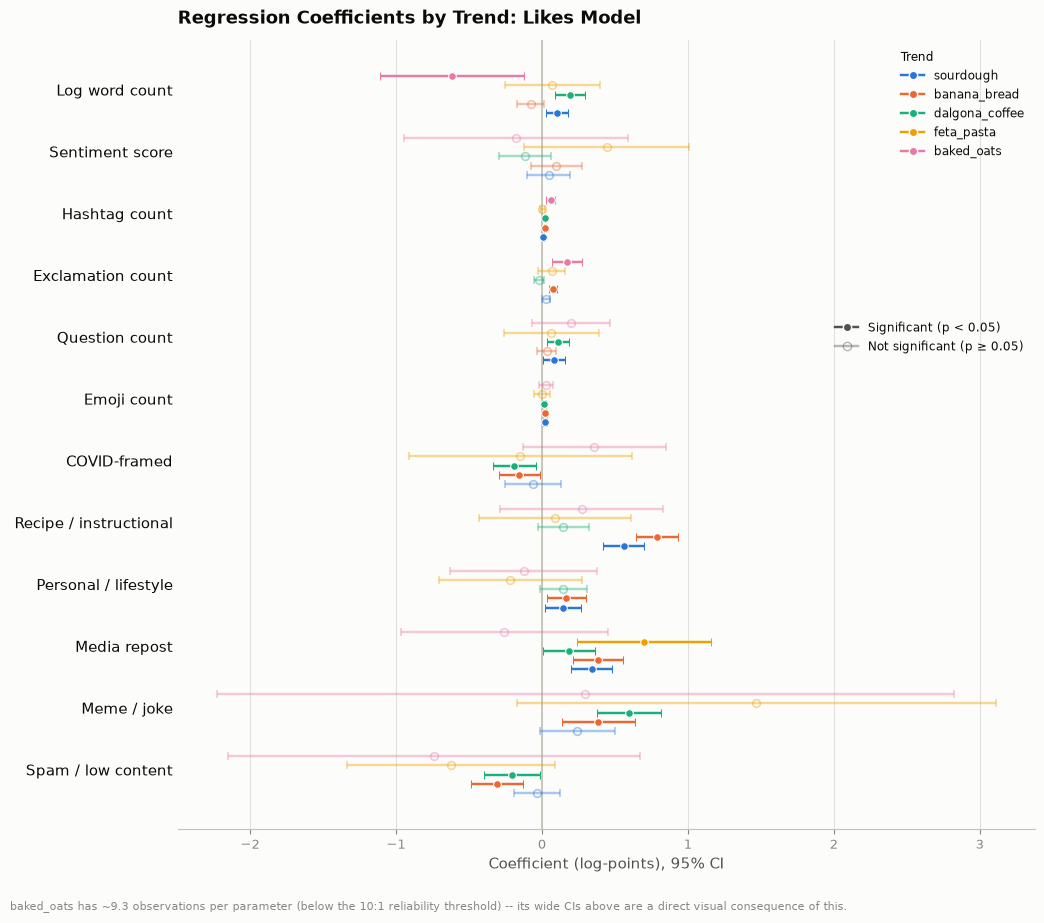

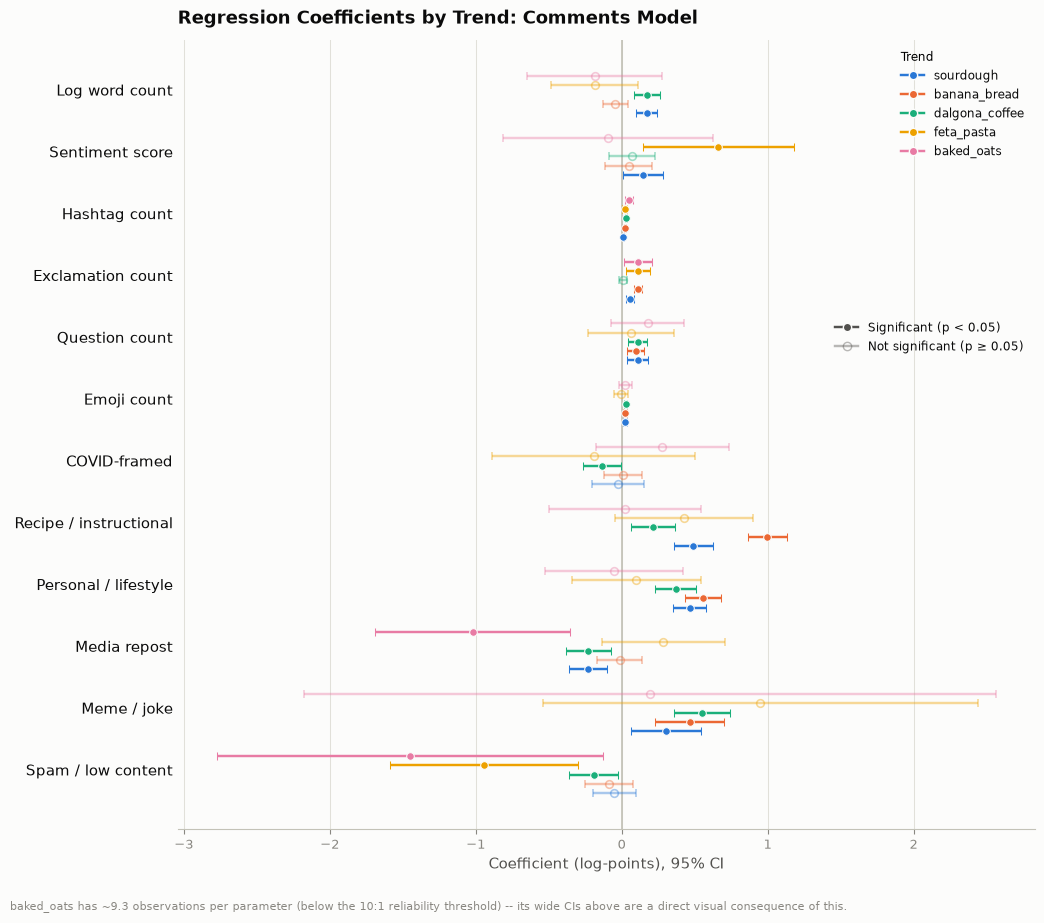

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Validated categorical palette (fixed order), same as the combined-model forest plot
TREND_COLORS = {
    "sourdough": "#2a78d6",       # slot 1 blue
    "banana_bread": "#eb6834",    # slot 2 orange
    "dalgona_coffee": "#1baf7a",  # slot 3 aqua
    "feta_pasta": "#eda100",      # slot 4 yellow
    "baked_oats": "#e87ba4",      # slot 5 magenta
}
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
SIG_ALPHA = 1.0
NONSIG_ALPHA = 0.4  # "more faded line" for p >= 0.05

predictor_label_map = {
    "log_word_count": "Log word count", "sentiment_score": "Sentiment score",
    "hashtag_count": "Hashtag count", "exclamation_count": "Exclamation count",
    "question_count": "Question count", "emoji_count": "Emoji count",
    "is_covid_framed": "COVID-framed",
    "is_recipe_instructional": "Recipe / instructional", "is_personal_lifestyle": "Personal / lifestyle",
    "is_media_repost": "Media repost", "is_meme_joke": "Meme / joke",
    "is_spam_low_content": "Spam / low content",
}

def forest_plot(outcome_key, title, filename):
    predictors_to_plot = rule_based_cols + ["is_covid_framed"] + zero_shot_cols  # excludes "const"
    n_pred = len(predictors_to_plot)
    fig, ax = plt.subplots(figsize=(10.5, 0.6 * n_pred + 2), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    offset_step = 0.15

    y_positions = np.arange(n_pred)[::-1]

    for pred_idx, predictor in enumerate(predictors_to_plot):
        y_base = y_positions[pred_idx]
        for trend_idx, trend in enumerate(trends_to_model):
            model = results[trend][outcome_key]
            coef = model.params[predictor]
            pval = model.pvalues[predictor]
            ci_low, ci_high = model.conf_int().loc[predictor]
            y_pos = y_base + (trend_idx - len(trends_to_model) / 2) * offset_step
            sig = pval < 0.05
            color = TREND_COLORS[trend]

            # Significant: solid marker, full-opacity line. Not significant: hollow marker
            # (transparent fill, colored edge so the trend is still identifiable), faded line.
            ax.errorbar(coef, y_pos, xerr=[[coef - ci_low], [ci_high - coef]],
                        fmt="o",
                        color=color,
                        markersize=5.5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=SURFACE if sig else color,
                        markeredgewidth=0.75 if sig else 1.2,
                        alpha=SIG_ALPHA if sig else NONSIG_ALPHA,
                        capsize=3, lw=1.75, zorder=2)

    ax.axvline(0, color=BASELINE, linewidth=1.25, zorder=1)
    ax.xaxis.grid(True, color=GRIDLINE, lw=0.75, zorder=0)
    ax.set_axisbelow(True)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([predictor_label_map[p] for p in predictors_to_plot],
                         color=INK_PRIMARY, fontsize=10.5)
    ax.tick_params(axis="y", length=0)
    ax.set_xlabel("Coefficient (log-points), 95% CI", color=INK_SECONDARY, fontsize=10.5)
    ax.tick_params(axis="x", colors=INK_MUTED, labelsize=9.5)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)

    ax.set_title(title, color=INK_PRIMARY, fontsize=13, fontweight="bold", loc="left", pad=12)

    # Two-part legend: trend color (left) + significance encoding (right), since color and
    # fill/opacity carry two independent pieces of information here
    trend_handles = [
        Line2D([0], [0], marker="o", color=TREND_COLORS[t], lw=1.75, markersize=6,
               markerfacecolor=TREND_COLORS[t], markeredgecolor=SURFACE, label=t)
        for t in trends_to_model
    ]
    sig_handles = [
        Line2D([0], [0], marker="o", color=INK_SECONDARY, lw=1.75, markersize=6,
               markerfacecolor=INK_SECONDARY, markeredgecolor=SURFACE, alpha=SIG_ALPHA,
               label="Significant (p < 0.05)"),
        Line2D([0], [0], marker="o", color=INK_SECONDARY, lw=1.75, markersize=6,
               markerfacecolor="none", markeredgecolor=INK_SECONDARY, alpha=NONSIG_ALPHA,
               label="Not significant (p \u2265 0.05)"),
    ]
    legend1 = ax.legend(handles=trend_handles, loc="upper right", fontsize=8.5, frameon=False,
                          labelcolor=INK_PRIMARY, title="Trend", title_fontsize=8.5,
                          alignment="left")
    ax.add_artist(legend1)
    ax.legend(handles=sig_handles, loc="upper right", bbox_to_anchor=(1, 1 - 0.052 * (len(trends_to_model) + 1.6)),
              fontsize=8.5, frameon=False, labelcolor=INK_PRIMARY, alignment="left")

    fig.text(0.01, 0.005,
              "baked_oats has ~9.3 observations per parameter (below the 10:1 reliability "
              "threshold) -- its wide CIs above are a direct visual consequence of this.",
              fontsize=8, color=INK_MUTED)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig(f"../../output/regression/{filename}", dpi=150, facecolor=SURFACE)
    plt.show()

import os
os.makedirs("../../output/regression", exist_ok=True)

forest_plot("likes", "Regression Coefficients by Trend: Likes Model",
            "forest_plot_likes.png")
forest_plot("comments", "Regression Coefficients by Trend: Comments Model",
            "forest_plot_comments.png")

## Step 5: R² comparison

In [6]:
for trend in trends_to_model:
    print(f"{trend}: likes R2 = {results[trend]['likes'].rsquared:.3f}, "
          f"comments R2 = {results[trend]['comments'].rsquared:.3f}, "
          f"n = {len(subsets[trend]['data'])}")

sourdough: likes R2 = 0.080, comments R2 = 0.161, n = 3000
banana_bread: likes R2 = 0.124, comments R2 = 0.212, n = 3000
dalgona_coffee: likes R2 = 0.080, comments R2 = 0.170, n = 3000
feta_pasta: likes R2 = 0.115, comments R2 = 0.169, n = 302
baked_oats: likes R2 = 0.316, comments R2 = 0.346, n = 121


## Step 6: Multicollinearity check (VIF), per trend

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for trend in trends_to_model:
    X = sm.add_constant(subsets[trend]["X"].astype(float))
    vif_data = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    print(f"\n=== {trend}: VIF ===")
    print(vif_data.to_string(index=False))


=== sourdough: VIF ===
                feature       VIF
                  const 31.676671
         log_word_count  2.216978
        sentiment_score  1.486404
          hashtag_count  1.123494
      exclamation_count  1.231911
         question_count  1.091756
            emoji_count  1.186892
        is_covid_framed  1.037759
is_recipe_instructional  1.210238
  is_personal_lifestyle  1.343875
        is_media_repost  1.161903
           is_meme_joke  1.049841
    is_spam_low_content  1.585979

=== banana_bread: VIF ===
                feature       VIF
                  const 41.606382
         log_word_count  2.475417
        sentiment_score  1.455432
          hashtag_count  1.149699
      exclamation_count  1.225982
         question_count  1.090471
            emoji_count  1.183004
        is_covid_framed  1.053707
is_recipe_instructional  1.475391
  is_personal_lifestyle  1.298616
        is_media_repost  1.132928
           is_meme_joke  1.055033
    is_spam_low_content  1.6555


=== dalgona_coffee: VIF ===
                feature       VIF
                  const 33.628257
         log_word_count  2.682382
        sentiment_score  1.426669
          hashtag_count  1.317842
      exclamation_count  1.213734
         question_count  1.088543
            emoji_count  1.113492
        is_covid_framed  1.073160
is_recipe_instructional  1.501581
  is_personal_lifestyle  1.467115
        is_media_repost  1.330314
           is_meme_joke  1.102174
    is_spam_low_content  1.848258

=== feta_pasta: VIF ===
                feature       VIF
                  const 39.761763
         log_word_count  2.730620
        sentiment_score  1.511397
          hashtag_count  1.254973
      exclamation_count  1.475299
         question_count  1.094014
            emoji_count  1.503025
        is_covid_framed  1.038203
is_recipe_instructional  1.885264
  is_personal_lifestyle  1.477612
        is_media_repost  1.240758
           is_meme_joke  1.058920
    is_spam_low_content  1.3


=== baked_oats: VIF ===
                feature       VIF
                  const 86.750860
         log_word_count  2.150288
        sentiment_score  1.369462
          hashtag_count  1.164287
      exclamation_count  1.367476
         question_count  1.222619
            emoji_count  1.424107
        is_covid_framed  1.132282
is_recipe_instructional  1.452970
  is_personal_lifestyle  1.244829
        is_media_repost  1.228961
           is_meme_joke  1.057072
    is_spam_low_content  1.286892
